In [ ]:
!pip install jax "jax[cuda13]" transformers huggingface_hub

# EfficientNet

**Paper:** [arXiv:1905.11946](https://arxiv.org/abs/1905.11946) — *EfficientNet: Rethinking Model Scaling for Convolutional Neural Networks* (Tan & Le, Google Brain, 2019).   
**Labels source:** [lukemelas/EfficientNet-PyTorch](https://github.com/lukemelas/EfficientNet-PyTorch/blob/master/examples/simple/labels_map.txt).   
**HF source:**: [google/efficientnet-b0](https://huggingface.co/google/efficientnet-b0)

This notebook walks through a **from-scratch JAX implementation** of EfficientNet-B0.

---

### Paper Overview

EfficientNet makes **one central claim**: the standard practice of scaling only *one* of depth, width, or resolution is suboptimal. The paper proposes **Compound Scaling** — scaling all three dimensions *jointly* with a single coefficient.

| Innovation | What it solves |
|---|---|
| **Compound Scaling** | Jointly scales depth, width, resolution via a fixed ratio | 
| **MBConv + SE Block** | Efficient building block with channel attention |
| **Swish (SiLU) activation** | Smoother than ReLU, better gradient flow |
| **NAS baseline (B0)** | Architecture found by neural architecture search |

### Architecture at a glance (EfficientNet-B0)

```
Input (224×224×3) — channels-first: (3, 224, 224)
  ↓  Stem: 3×3 conv, stride 2 → 32ch, 112×112
Stage 1:  1× MBConv1 (k=3, s=1,  32→16)
Stage 2:  2× MBConv6 (k=3, s=2,  16→24)
Stage 3:  2× MBConv6 (k=5, s=2,  24→40)
Stage 4:  3× MBConv6 (k=3, s=2,  40→80)
Stage 5:  3× MBConv6 (k=5, s=1,  80→112)
Stage 6:  4× MBConv6 (k=5, s=2, 112→192)
Stage 7:  1× MBConv6 (k=3, s=1, 192→320)
  ↓  Head: 1×1 conv → 1280ch + BN + SiLU
  ↓  Global Average Pool → (1280,)
  ↓  Linear → 1000 classes
```

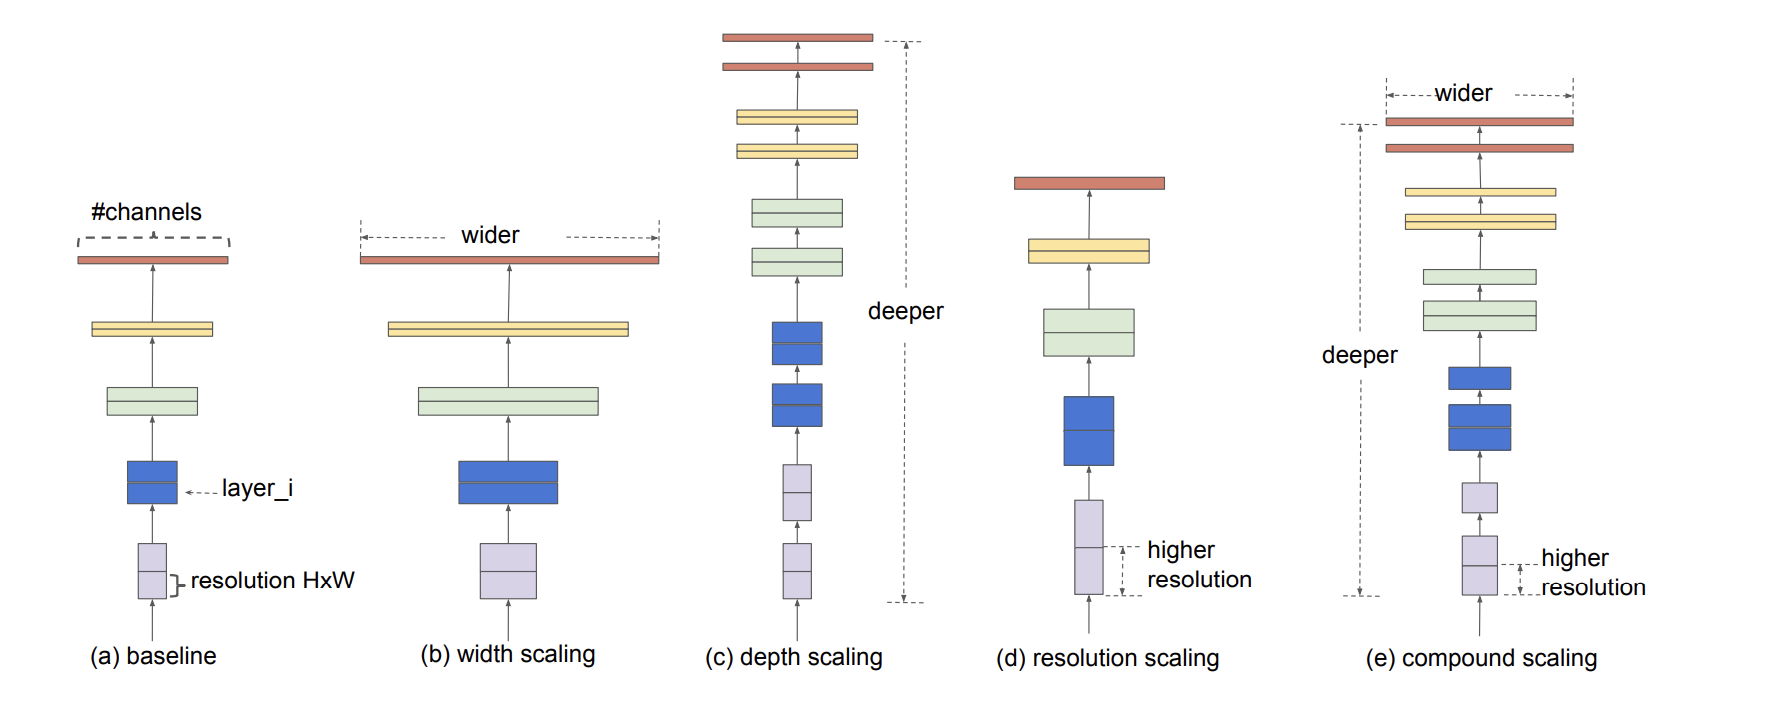

### Imports

In [ ]:
import json
from dataclasses import dataclass

import numpy as np
import jax
import jax.numpy as jnp
import jax.nn as jnn
import PIL.Image as Image
from safetensors.torch import load_file
from transformers import AutoTokenizer

**Setup:** Download the model weights and config from HuggingFace and place them at `models/dinov3/` relative to your workspace root.   
Labels Source File:
https://github.com/lukemelas/EfficientNet-PyTorch/blob/master/examples/simple/labels_map.txt

In [ ]:
HF_REPO_ID = "google/efficientnet-b0"
LOCAL_DIR_PATH = "workspace/models/efficientnet"

In this section, we download the weights of the model of interest from huggingface to use in our implementation.

In [ ]:
from huggingface_hub import snapshot_download

local_dir = snapshot_download(
    repo_id=HF_REPO_ID,
    local_dir=LOCAL_DIR_PATH,
)
print(f"Downloaded repository path: {local_dir}")

### Load Weights

EfficientNet-B0 is the baseline network found via Neural Architecture Search (NAS). The search optimizes for FLOP-efficient architectures, resulting in the specific stage configuration below. B1–B7 are then derived from B0 purely by compound scaling — **no new architectural blocks are introduced**.

In [ ]:
WEIGHTS_PATH = f"{LOCAL_DIR_PATH}/model.safetensors"
CONFIG_PATH = f"{LOCAL_DIR_PATH}/config.json"
LABELS_PATH = f"{LOCAL_DIR_PATH}/id2label.json"
IMAGE_PATH = f"{LOCAL_DIR_PATH}/cat.png"

checkpoint_path = WEIGHTS_PATH
hf_weights = load_file(checkpoint_path)

### Stage Configuration

The paper defines EfficientNet-B0 as 7 stages of MBConv blocks. Each stage is characterised by:

| Field | Meaning |
|---|---|
| `num_layers` | How many MBConv blocks repeat in this stage |
| `kernel_size` | Depthwise conv kernel (3×3 or 5×5) |
| `stride` | Applied only to the **first** block; rest use stride 1 |
| `expand_ratio` | Channel expansion inside the block (1× or 6×) |
| `input_channels` | Channels in |
| `output_channels` | Channels out |
| `se_ratio` | Squeeze-and-Excitation bottleneck ratio |


In [4]:
@dataclass
class EfficientNetStageConfig:
    num_layers: int
    kernel_size: int
    stride: int    
    expand_ratio: int
    input_channels: int     
    output_channels: int
    se_ratio: float = 0.25

STAGES = [
    EfficientNetStageConfig(1, 3, 1, 1, 32, 16),
    EfficientNetStageConfig(2, 3, 2, 6, 16, 24),
    EfficientNetStageConfig(2, 5, 2, 6, 24, 40),
    EfficientNetStageConfig(3, 3, 2, 6, 40, 80),
    EfficientNetStageConfig(3, 5, 1, 6, 80, 112),
    EfficientNetStageConfig(4, 5, 2, 6, 112, 192),
    EfficientNetStageConfig(1, 3, 1, 6, 192, 320),
]

### Weight Extraction

Each MBConv block has a fixed set of sub-layers:
- `conv_pw` — pointwise **expansion** conv (only present when `expand_ratio 1`, i.e. stages 2–7)
- `conv_dw` — **depthwise** conv (3×3 or 5×5 kernel)
- `se` — Squeeze-and-Excitation module
- `conv_pwl` — pointwise **projection** conv (linear, no activation)
- `bn1/bn2/bn3` — Batch Normalization after each conv

Stage 1 uses `expand_ratio=1`, so there is **no expansion conv** and only 2 batch norms (one after dw, one after projection). This is reflected in the conditional weight loading below.

In [5]:
def get_w(
    name: str,
    transpose: bool = False
) -> jax.Array:
    val = hf_weights.pop(name)
    w = jnp.array(val.float(), dtype=jnp.bfloat16)
    return w.T if transpose else w

blocks = []
for i in range(7):
    for j in range(STAGES[i].num_layers):
        block = {
            'stage': i + 1,
            'layer': j + 1,
            'conv': {
                'dw': get_w(f'blocks.{i}.{j}.conv_dw.weight'),
                'pw': get_w(f'blocks.{i}.{j}.conv_pw.weight'),
                'pwl': get_w(f'blocks.{i}.{j}.conv_pwl.weight') if i > 0 else None
            },
            'bn': [{
                'weight': get_w(f'blocks.{i}.{j}.bn{k + 1}.weight'),
                'bias': get_w(f'blocks.{i}.{j}.bn{k + 1}.bias'),
                'running_mean': get_w(f'blocks.{i}.{j}.bn{k + 1}.running_mean'),
                'running_var': get_w(f'blocks.{i}.{j}.bn{k + 1}.running_var')
            } for k in range(3 if i > 0 else 2)],
            'se': {
                'expand': {
                    'weight': get_w(f'blocks.{i}.{j}.se.conv_expand.weight'),
                    'bias': get_w(f'blocks.{i}.{j}.se.conv_expand.bias')
                },
                'reduce': {
                    'weight': get_w(f'blocks.{i}.{j}.se.conv_reduce.weight'),
                    'bias': get_w(f'blocks.{i}.{j}.se.conv_reduce.bias')
                }
            }
        }
        blocks.append(block)

m = {
    'blocks': blocks,
    'bn': [{
        'weight': get_w(f'bn{j + 1}.weight'),
        'bias': get_w(f'bn{j + 1}.bias'),
        'running_mean': get_w(f'bn{j + 1}.running_mean'),
        'running_var': get_w(f'bn{j + 1}.running_var')
    } for j in range(2)],
    'conv_stem': get_w('conv_stem.weight'),
    'classifier': {
        'weight': get_w('classifier.weight'),
        'bias': get_w('classifier.bias')
    },
    'conv_head': get_w('conv_head.weight')
}


**Resolution scaling (3.2):** For B1–B7, the input resolution increases per the compound scaling formula. B0 = 224, B1 = 240, B2 = 260, B3 = 300, B4 = 380, B5 = 456, B6 = 528, B7 = 600. All scaling flows from the single compound coefficient φ.

In [6]:
def preprocess(
    image_path: str,
    target_size: tuple[int, int] = (224, 224)
) -> jax.Array:                                 # (B, 3, H, W)
    img = Image.open(image_path).convert("RGB")
    img_resized = img.resize(
        (target_size[1], target_size[0]),
        resample=Image.BILINEAR
    )
    x = jnp.array(np.array(img_resized), dtype=jnp.float32) / 255.0
    mean = jnp.array([0.485, 0.456, 0.406])
    std = jnp.array([0.229, 0.224, 0.225])
    x = (x - mean) / std
    x = x.astype(jnp.bfloat16)
    x = x[None, ...]
    x = x.transpose(0, 3, 1, 2)
    return x


### Stem

**3.1 (Baseline Network):** The stem is a standard 3×3 convolution with stride 2, bringing the 224×224 input down to 112×112 while expanding from 3 to 32 channels. This is followed by BN and **Swish** activation.

**Swish / SiLU (3.1):** The paper uses Swish (`x · σ(x)`) as the activation function throughout, in place of the ReLU used in earlier MobileNet variants. Swish is smooth and non-monotonic, which is found to be superior to ReLU for this architecture.

In [7]:
def batch_norm_inference(
    x: jax.Array,       # (B, C, H, W)
    params: dict,
    epsilon: float = 1e-5
) -> jax.Array:
    s = params['weight'].reshape(1, -1, 1, 1)
    b = params['bias'].reshape(1, -1, 1, 1)
    m = params['running_mean'].reshape(1, -1, 1, 1)
    v = params['running_var'].reshape(1, -1, 1, 1)

    inv_std = jax.lax.rsqrt(v + epsilon)
    normalized = (x - m) * inv_std

    return normalized * s + b

def efficientnet_stem(
    x: jax.Array,   # (B, 3, 224, 224)
    params: dict
) -> jax.Array:     # (B, 32, 112, 112)
    x = jax.lax.conv_general_dilated(
        lhs=x,
        rhs=params['conv_stem'],
        window_strides=(2, 2),
        padding='SAME',
        dimension_numbers=('NCHW', 'OIHW', 'NCHW')
    )
    x = batch_norm_inference(x, params['bn'][0], epsilon=1e-5)
    return jnn.silu(x)


### Squeeze-and-Excitation (SE)

**3.1 + SE paper (Hu et al. 2018):** Squeeze-and-Excitation is a lightweight **channel attention** mechanism embedded inside every MBConv block. The paper adopts it with `se_ratio=0.25` (reduce to 1/4 of the *input* channels, not expanded channels).

The mechanism has two steps:

**Squeeze:** Global Average Pooling collapses spatial dimensions → `(B, C, 1, 1)`  
This gives each channel a single scalar representing its global average activation — a "global descriptor".

**Excitation:** Two small 1×1 convolutions form a bottleneck:
```
C → C/4  (reduce, with SiLU)
C/4 → C  (expand, with Sigmoid)
```
The sigmoid output is a per-channel **weight in [0,1]** — a soft mask that amplifies informative channels and suppresses uninformative ones.

The final `x * se_weight` operation re-scales each channel of the feature map by its learned importance score.

**Where SE fits in the block:** SE is applied *after* the depthwise conv and *before* the projection conv — it operates on the expanded (wide) representation, then the projection compresses it back.

In [8]:
def squeeze_excitation(
    x: jax.Array,   # (B, C, H, W)
    params: dict
) -> jax.Array:     # (B, C, H, W)
    
    se_weight = jnp.mean(x, axis=(2, 3), keepdims=True)    # (B, C, 1, 1)

    se_weight = jax.lax.conv_general_dilated(
        se_weight,
        params['reduce']['weight'],
        window_strides=(1, 1),
        padding='VALID',
        dimension_numbers=('NCHW', 'OIHW', 'NCHW')
    )
    se_weight = se_weight + params['reduce']['bias'].reshape(1, -1, 1, 1)
    se_weight = jax.nn.silu(se_weight)

    se_weight = jax.lax.conv_general_dilated(
        se_weight,
        params['expand']['weight'],
        window_strides=(1, 1),
        padding='VALID',
        dimension_numbers=('NCHW', 'OIHW', 'NCHW')
    )
    se_weight = se_weight + params['expand']['bias'].reshape(1, -1, 1, 1)
    se_weight = jax.nn.sigmoid(se_weight)

    return x * se_weight


### MBConv Block

The **Mobile Inverted Bottleneck Convolution** (MBConv) is the core building block of EfficientNet, inherited from MobileNetV2 and enhanced with Squeeze-and-Excitation.

The full block for stages 2–7 (`expand_ratio=6`):

```
x_in ────────────────────────────────────────► (+) ──► x_out
        │                                       ▲
        ▼                                       │ (skip only if
  PWConv 1×1 (expand ×6)                        │  stride=1 AND
    BN + SiLU                                   │  C_in = C_out)
        │
  DWConv k×k (stride s)         ← 3×3 or 5×5 (Table 1)
    BN + SiLU
        │
  Squeeze-and-Excitation        ← channel attention
        │
  PWConv 1×1 (project → C_out)  ← NO activation ("linear bottleneck")
    BN
        │
        └────────────────────────────────────────┘
```

Stage 1 (`expand_ratio=1`) skips the first PWConv entirely — there is nothing to expand.

**Skip connection rule:** A residual shortcut is used **only** when `stride=1` AND `C_in == C_out`. In this implementation:
- `layer == 1` → first block of a stage → use the stage's stride, no skip
- `layer 1` → subsequent blocks within a stage → `stride=1`, use skip

**"Linear bottleneck" (from MobileNetV2):** The final projection conv has **no activation** — BN only. This preserves the information capacity of the low-dimensional projected space.

In [9]:
def mb_conv_block(
    x: jax.Array,       # (B, C, H, W)
    params: dict,
    stride: int = 1,
    has_skip: bool = False
) -> jax.Array:         # (B, C', H', W')
    identity = x

    if 'pw' in params['conv'] and params['conv']['pwl'] is not None:
        x = jax.lax.conv_general_dilated(
            x, params['conv']['pw'], (1, 1), 'SAME',
            dimension_numbers=('NCHW', 'OIHW', 'NCHW')
        )
        x = batch_norm_inference(x, params['bn'][0])
        x = jax.nn.silu(x)

        proj_weight = params['conv']['pwl']
        proj_bn = params['bn'][2]
        dw_bn = params['bn'][1]
    else:
        proj_weight = params['conv']['pw']
        proj_bn = params['bn'][1]
        dw_bn = params['bn'][0]

    channels = x.shape[1]
    x = jax.lax.conv_general_dilated(
        x, params['conv']['dw'], (stride, stride), 'SAME',
        feature_group_count=channels,
        dimension_numbers=('NCHW', 'OIHW', 'NCHW')
    )
    x = batch_norm_inference(x, dw_bn)
    x = jnn.silu(x)

    if 'se' in params:
        x = squeeze_excitation(x, params['se'])

    x = jax.lax.conv_general_dilated(
        x, proj_weight, (1, 1), 'SAME',
        dimension_numbers=('NCHW', 'OIHW', 'NCHW')
    )
    x = batch_norm_inference(x, proj_bn)

    return x + identity if has_skip else x


### Head

**3.1 (Baseline Network):** After all 7 stages, a 1×1 "head" convolution expands the 320-channel feature map to **1280 channels**, followed by BN and SiLU. Then global average pooling reduces the 7×7 spatial map to a single 1280-dim vector.

This design is intentional: the wide (1280-dim) pooled representation before the final linear layer gives the classifier more capacity without adding large spatial computation.

For larger models (B1–B7), this head stays at 1280 channels — **only the backbone stages are scaled** by the compound coefficient. The classifier head width is fixed across the entire EfficientNet family.

In [10]:
def efficientnet_head(
    x: jax.Array,   # (B, 320, 7, 7)
    params: dict
) -> jax.Array:     # (B, 1000)
    x = jax.lax.conv_general_dilated(
        x, params['conv_head'], (1, 1), 'SAME',
        dimension_numbers=('NCHW', 'OIHW', 'NCHW')
    )
    x = batch_norm_inference(x, params['bn'][1])
    x = jax.nn.silu(x)
    x = jnp.mean(x, axis=(2, 3))

    logits = jnp.dot(x, params['classifier']['weight'].T) + params['classifier']['bias']

    return logits


### Full Forward Pass

- The **first block** of each stage applies the stage's stride and has **no skip** (input/output channels differ)
- All **subsequent blocks** within a stage use `stride=1` and have a skip connection (channels are equal)

This is why the STAGES table specifies only one stride per stage — it only applies to `layer 1`.

**Compound Scaling:** To scale B0 → B1:
The architecture below would require updating `STAGES` channel/depth values and `preprocess()` resolution to apply this — but the block structure remains identical.

In [11]:
def efficientnet_b0_forward(
    x: jax.Array,   # (B, 3, 224, 224)
    params: dict
) -> jax.Array:     # (B, 1000)
    x = efficientnet_stem(x, params)

    for index, block_params in enumerate(params['blocks']):
        if block_params['layer'] == 1:
            stage = block_params['stage'] - 1
            stride = STAGES[stage].stride
            has_skip = False
        else:
            stride = 1
            has_skip = True

        x = mb_conv_block(x, block_params, stride=stride, has_skip=has_skip)

    logits = efficientnet_head(x, params)

    return logits


In [12]:
image = preprocess(IMAGE_PATH)
print(image.shape)

(1, 3, 224, 224)


In [13]:
result = efficientnet_b0_forward(image, m)
print(result.shape)

(1, 1000)


In [14]:
logits = result
probs = jax.nn.softmax(logits, axis=-1)

top5_indices = jnp.argsort(probs[0])[::-1][:5]
top5_probabilities = probs[0][top5_indices]

print(f"Top 5 indices: {top5_indices}")
print(f"Top 5 probabilities: {top5_probabilities}")

Top 5 indices: [282 281 285 782 904]
Top 5 probabilities: [0.796875 0.0810547 0.0256348 0.00315857 0.00179291]


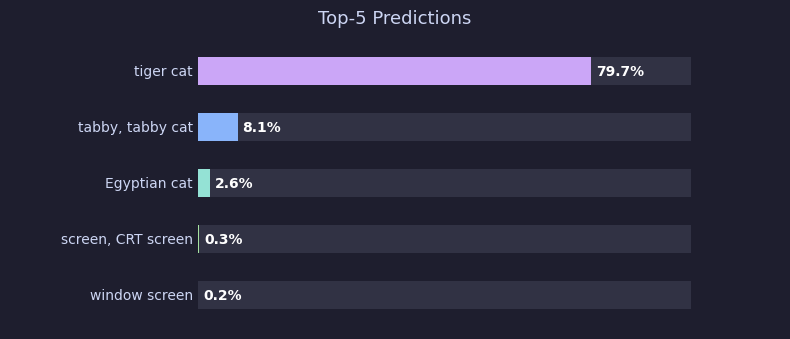

In [15]:
import matplotlib.pyplot as plt
import numpy as np

with open(LABELS_PATH, 'r') as f:
    index_to_label = json.load(f)

labels = [index_to_label[str(int(idx))] for idx in top5_indices]
probs_np = np.array(top5_probabilities, dtype=float)

labels = labels[::-1]
probs_np = probs_np[::-1]

fig, ax = plt.subplots(figsize=(8, 3.5))
fig.patch.set_facecolor('#1e1e2e')
ax.set_facecolor('#1e1e2e')

bar_h = 0.5
colors = ['#cba6f7', '#89b4fa', '#94e2d5', '#a6e3a1', '#f9e2af'][::-1]

for i, (label, prob, color) in enumerate(zip(labels, probs_np, colors)):
    ax.barh(i, 1.0, height=bar_h, color='#313244', left=0)
    ax.barh(i, prob,  height=bar_h, color=color,    left=0)
    ax.text(prob + 0.01, i, f'{prob*100:.1f}%', va='center', ha='left',
            color='white', fontsize=10, fontweight='bold')
    ax.text(-0.01, i, label, va='center', ha='right',
            color='#cdd6f4', fontsize=10)

ax.set_xlim(-0.38, 1.18)
ax.set_ylim(-0.6, len(labels) - 0.4)
ax.axis('off')
ax.set_title('Top-5 Predictions', color='#cdd6f4', fontsize=13, pad=10)

plt.tight_layout()
plt.show()


In [16]:
x = preprocess(IMAGE_PATH)
x = efficientnet_stem(x, m)

stage_outputs = {}
for block_params in m['blocks']:
    stage = block_params['stage']
    layer = block_params['layer']
    stride = STAGES[stage - 1].stride if layer == 1 else 1
    x = mb_conv_block(x, block_params, stride=stride, has_skip=(layer != 1))
    stage_outputs[stage] = x

x = jax.lax.conv_general_dilated(x, m['conv_head'], (1, 1), 'SAME', dimension_numbers=('NCHW', 'OIHW', 'NCHW'))

x = batch_norm_inference(x, m['bn'][1])
pre_gap = jax.nn.silu(x)                    # (B, 1280, 7, 7)

for k, v in stage_outputs.items():
    print(f"Stage {k} output shape: {v.shape}")
print("pre_gap:", pre_gap.shape)


Stage 1 output shape: (1, 16, 112, 112)
Stage 2 output shape: (1, 24, 56, 56)
Stage 3 output shape: (1, 40, 28, 28)
Stage 4 output shape: (1, 80, 14, 14)
Stage 5 output shape: (1, 112, 14, 14)
Stage 6 output shape: (1, 192, 7, 7)
Stage 7 output shape: (1, 320, 7, 7)
pre_gap: (1, 1280, 7, 7)


### Class Activation Map (CAM)

EfficientNet ends with GAP → linear, so exact CAM works: weight the `7×7×1280` pre-GAP feature map by the classifier weights for the top predicted class, sum across channels, then upsample.


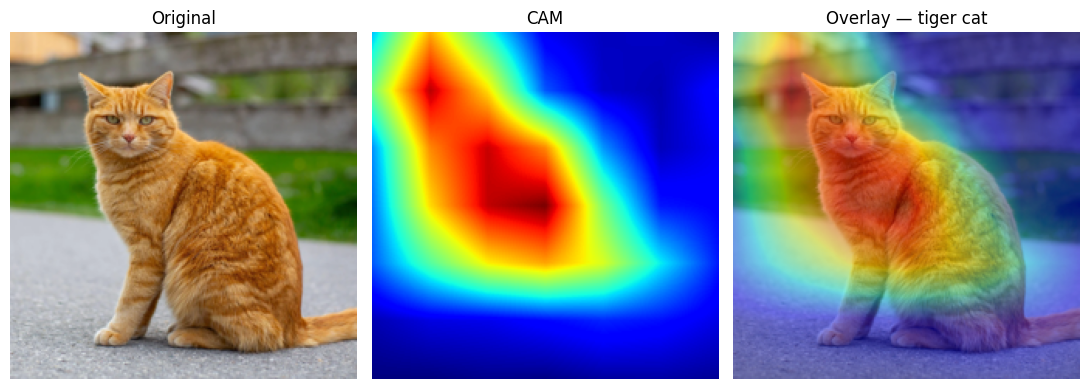

In [17]:
import scipy.ndimage

top_class = int(top5_indices[0])

feat = np.array(pre_gap[0], dtype=np.float32)                           # (1280, 7, 7)
w = np.array(m['classifier']['weight'][top_class], dtype=np.float32)    # (1280,)

cam = np.einsum('chw,c->hw', feat, w)                                   # (7, 7)
cam = np.maximum(cam, 0)
cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)
cam = scipy.ndimage.zoom(cam, 224 / 7, order=1)                         # (224, 224)

img_arr = np.array(Image.open(IMAGE_PATH).convert("RGB").resize((224, 224)))

fig, axes = plt.subplots(1, 3, figsize=(11, 4))

axes[0].imshow(img_arr)                
axes[0].set_title("Original")
axes[1].imshow(cam, cmap="jet")    
axes[1].set_title("CAM")
axes[2].imshow(img_arr)
axes[2].imshow(cam, cmap="jet", alpha=0.45) 
axes[2].set_title(f"Overlay — {index_to_label[str(top_class)]}")

for ax in axes: 
    ax.axis("off")

plt.tight_layout()
plt.show()

### Multi-Scale Feature Maps

Each stage halves the spatial resolution and doubles the channels. A single representative channel from each stage's output is shown below — from fine-grained edges (112×112) to coarse semantic blobs (7×7).


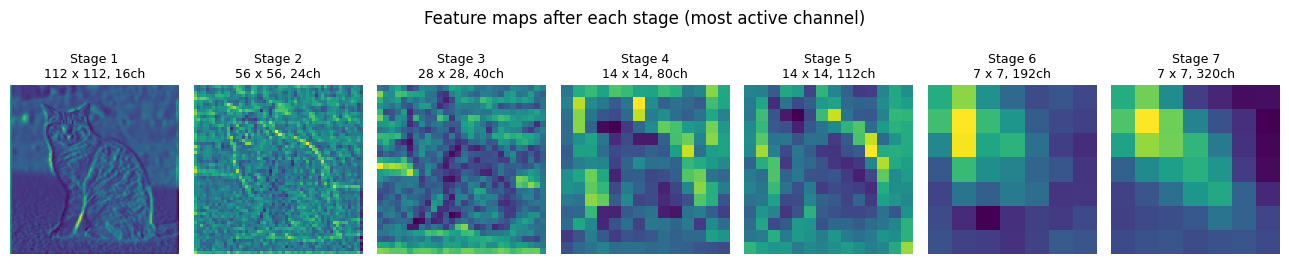

In [18]:
stage_keys = sorted(stage_outputs.keys())
spatial_sizes = [112, 56, 28, 14, 14, 7, 7]

fig, axes = plt.subplots(1, len(stage_keys), figsize=(13, 3))
for ax, s in zip(axes, stage_keys):
    feat = np.array(stage_outputs[s][0], dtype=np.float32)      # (C, H, W)
    ch = np.argmax(feat.max(axis=(1, 2)))                    # pick most-active channel
    fmap = feat[ch]
    ax.imshow(fmap, cmap='viridis')
    ax.set_title(f"Stage {s}\n{feat.shape[1]} x {feat.shape[2]}, {feat.shape[0]}ch", fontsize=9)
    ax.axis('off')

plt.suptitle('Feature maps after each stage (most active channel)', fontsize=12)
plt.tight_layout()
plt.show()
